<a href="https://www.kaggle.com/code/mahmoudashrey/pima-indians-diabetes?scriptVersionId=348565484" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Diabetes Dataset — EDA & Visualization

## Project Overview

This project explores a dataset of 768 female patients to identify patterns and relationships associated with diabetes.

The analysis focuses on data cleaning, exploratory data analysis (EDA), and visualization using Python. The main objective is to understand how variables such as glucose, BMI, age, insulin, and number of pregnancies differ between diabetic and non-diabetic patients.

### Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

### Analysis Workflow

1. Data Loading & Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Data Visualization
5. Key Insights & Findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
zero_counts = (df == 0).sum()

zero_counts

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [11]:
zero_percentage = ((df == 0).sum() / len(df) * 100).round(2)

pd.DataFrame({
    "Zero Count": zero_counts,
    "Zero Percentage": zero_percentage
})

,Zero Count,Zero Percentage
Pregnancies,111,14.45
Glucose,0,0.00
BloodPressure,0,0.00
SkinThickness,0,0.00
Insulin,0,0.00
BMI,0,0.00
DiabetesPedigreeFunction,0,0.00
Age,0,0.00
Outcome,500,65.10


In [12]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

### Cleaning Summary

- No missing values were found.
- No duplicate rows were found.
- Zero values were only present in `Pregnancies` and `Outcome`, where they represent valid observations.
- The remaining numerical variables contained no zero values.
- All variables have appropriate numerical data types for analysis.

# Exploratory Data Analysis & Visualization

The following analysis explores the distribution of diabetes outcomes and examines the relationship between diabetes status and the main numerical variables.

## Diabetes Outcome Distribution

Before analyzing the relationships between the different variables, we first examine the distribution of the target variable, `Outcome`.

In [14]:
outcome_counts = df['Outcome'].value_counts().sort_index()

outcome_df = pd.DataFrame({
    'Outcome': ['No Diabetes', 'Diabetes'],
    'Count': outcome_counts.values
})

fig = px.bar(
    outcome_df,
    x = 'Outcome',
    y = 'Count',
    text = 'Count',
    title = 'Diabetes Outcome Distribution',
    labels = {'Outcome': 'Diabetes Status', 'Count': 'Number of Patients'}
)

fig.update_traces(
    textposition = 'outside'
)

fig.update_layout(
    yaxis = dict(showgrid = True),
    title_x = 0.5
)

fig.show()

### Insight

The dataset contains 768 patients, with 500 (65.1%) classified as non-diabetic and 268 (34.9%) classified as diabetic. This shows that the dataset is not evenly distributed across the two outcome groups, with non-diabetic patients representing the larger share of the data.

## Glucose Levels by Diabetes Status

Glucose is one of the key variables associated with diabetes. 
We compare its distribution between patients with and without diabetes.

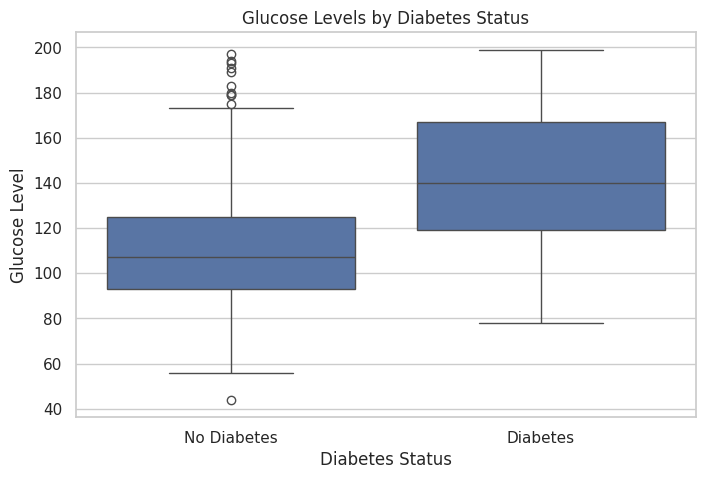

In [15]:
plt.figure(figsize = (8, 5))

sns.boxplot(
    data = df,
    x = 'Outcome',
    y = 'Glucose'
)

plt.title('Glucose Levels by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Glucose Level')

plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])

plt.show()

### Insight

Patients with diabetes have noticeably higher glucose levels than those without diabetes. 
The median glucose level is around 140 for the diabetes group compared with around 107 for the non-diabetes group. 
Although the two groups show some overlap, the overall distribution is clearly shifted toward higher glucose levels among diabetic patients.

## BMI Levels by Diabetes Status

BMI is another important variable to examine when comparing patients with and without diabetes. 
This visualization shows how BMI is distributed across the two outcome groups.

In [16]:
fig = px.box(
    df,
    x = 'Outcome',
    y = 'BMI',
    points = 'outliers',
    title = 'BMI Levels by Diabetes Status',
    labels = {
        'Outcome': 'Diabetes Status',
        'BMI': 'BMI'
    }
)

fig.update_xaxes(
    tickmode = 'array',
    tickvals = [0, 1],
    ticktext = ['No Diabetes', 'Diabetes']
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Patients with diabetes generally have higher BMI levels than non-diabetic patients. 
The median BMI is around 34–35 in the diabetes group compared with around 30 in the non-diabetes group. 
However, there is considerable overlap between the two groups, indicating that BMI alone does not clearly distinguish diabetes status.

## Age Distribution by Diabetes Status

Age may be associated with diabetes status. 
This visualization compares the age distribution of patients with and without diabetes.

In [17]:
fig = px.violin(
    df,
    x = 'Outcome',
    y = 'Age',
    box = True,
    points = False,
    title = 'Age Distribution by Diabetes Status',
    labels = {
        'Outcome': 'Diabetes Status',
        'Age': 'Age'
    }
)

fig.update_xaxes(
    tickmode = 'array',
    tickvals = [0, 1],
    ticktext = ['No Diabetes', 'Diabetes']
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Patients with diabetes tend to be older than those without diabetes. 
The median age is around 36 years for the diabetes group compared with around 27 years for the non-diabetes group. 
The diabetes group also shows a wider concentration across older ages, although there is considerable overlap between the two groups.

## Diabetes Rate by Number of Pregnancies

We examine how the proportion of patients with diabetes changes across different numbers of pregnancies.

In [18]:
pregnancy_rate = (
    df.groupby('Pregnancies')['Outcome']
      .mean()
      .reset_index()
)

pregnancy_rate['Diabetes Rate (%)'] = pregnancy_rate['Outcome'] * 100

fig = px.bar(
    pregnancy_rate,
    x = 'Pregnancies',
    y = 'Diabetes Rate (%)',
    text = 'Diabetes Rate (%)',
    title = 'Diabetes Rate by Number of Pregnancies',
    labels = {
        'Pregnancies': 'Number of Pregnancies',
        'Diabetes Rate (%)': 'Diabetes Rate (%)'
    }
)

fig.update_traces(
    texttemplate = '%{text:.1f}%',
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Diabetes rates vary across different numbers of pregnancies, with generally higher rates observed at higher pregnancy counts. However, the relationship is not consistently increasing across all pregnancy levels. The 100% rates observed at 14, 15, and 17 pregnancies should be interpreted cautiously because these groups contain very few observations.

## Correlation Analysis

A correlation matrix helps us understand the relationships between the numerical variables and identify which features are most strongly associated with the diabetes outcome.

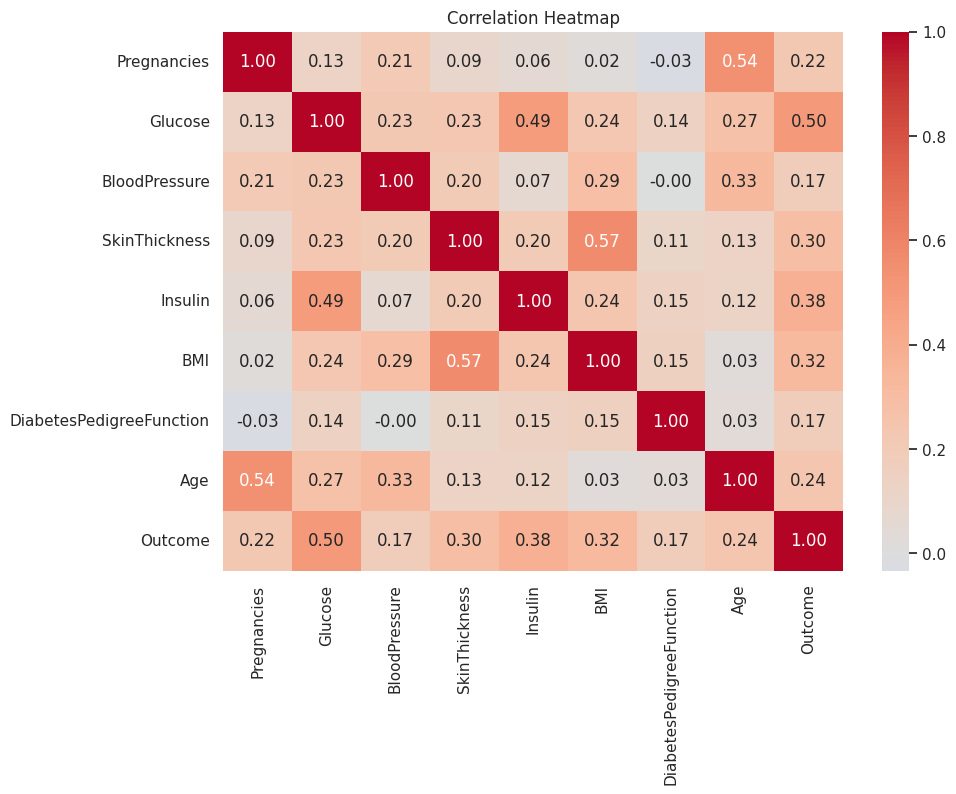

In [19]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0
)

plt.title('Correlation Heatmap')
plt.show()

### Insight

Glucose shows the strongest positive correlation with diabetes outcome (0.50), followed by Insulin (0.38), BMI (0.32), and SkinThickness (0.30). This indicates that glucose has the strongest linear association with diabetes status among the variables in the dataset. Other variables, such as Age and Pregnancies, show weaker positive correlations with the outcome.

The heatmap also shows moderate relationships between some features, such as SkinThickness and BMI (0.57) and Pregnancies and Age (0.54).

## Glucose vs BMI by Diabetes Status

Glucose and BMI showed relatively strong associations with the diabetes outcome.
This visualization examines the relationship between these two variables while distinguishing patients by diabetes status.

In [20]:
fig = px.scatter(
    df,
    x = 'Glucose',
    y = 'BMI',
    color = 'Outcome',
    title = 'Glucose vs BMI by Diabetes Status',
    labels = {
        'Glucose': 'Glucose Level',
        'BMI': 'BMI',
        'Outcome': 'Diabetes Status'
    },
    opacity = 0.7
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Diabetic patients are more concentrated at higher glucose levels, while non-diabetic patients are more concentrated at lower glucose levels. 
Although BMI varies across both groups, glucose appears to provide a clearer separation between diabetes outcomes in this visualization. 
There is still considerable overlap between the two groups, indicating that glucose and BMI together do not completely distinguish diabetes status.

## Key Metrics by Diabetes Status

To complement the visual analysis, we compare the average values of the main numerical variables between patients with and without diabetes.

In [21]:
key_metrics = [
    'Glucose',
    'BMI',
    'Age',
    'Pregnancies',
    'Insulin',
    'BloodPressure'
]

summary = df.groupby('Outcome')[key_metrics].mean().round(2)

summary.index = ['No Diabetes', 'Diabetes']

summary

,Glucose,BMI,Age,Pregnancies,Insulin,BloodPressure
No Diabetes,110.62,30.85,31.19,3.30,117.17,70.84
Diabetes,142.30,35.40,37.07,4.87,187.62,75.27


## Key Findings

- The dataset contains 768 patients, with 65.1% classified as non-diabetic and 34.9% classified as diabetic.

- Glucose shows the strongest association with diabetes outcome. Diabetic patients have a noticeably higher median and average glucose level than non-diabetic patients.

- BMI is generally higher among diabetic patients, with a median around 34–35 compared with around 30 for non-diabetic patients. However, the two groups show considerable overlap.

- Diabetic patients tend to be older, with an average age of 37.07 years compared with 31.19 years among non-diabetic patients.

- Diabetes rates vary across pregnancy counts, but the relationship is not consistently increasing. Very high rates at pregnancy counts such as 14, 15, and 17 should be interpreted cautiously because of the small number of observations in these groups.

- The correlation analysis shows that Glucose (0.50), Insulin (0.38), BMI (0.32), and SkinThickness (0.30) have the strongest positive correlations with the diabetes outcome.

- Overall, Glucose stands out as the most prominent variable associated with diabetes status in this dataset, while BMI, Age, Insulin, and other variables provide additional information.

# Conclusion

The exploratory analysis reveals several clear differences between diabetic and non-diabetic patients.

Glucose is the most prominent variable associated with diabetes status in this dataset, with diabetic patients showing substantially higher glucose levels. BMI and age also show noticeable differences between the two groups, while insulin and other variables provide additional information.

The analysis also shows that relationships are not always straightforward. For example, diabetes rates across pregnancy counts fluctuate rather than increasing consistently, and considerable overlap exists between diabetic and non-diabetic groups for several variables.

Overall, the analysis provides a clear understanding of the main patterns in the dataset and highlights the variables that are most strongly associated with diabetes outcome.